In [ ]:
from google.colab import files
uploaded = files.upload()

Saving crop_loan_dataset_realistic.xlsx to crop_loan_dataset_realistic.xlsx



Cross-Validation Accuracy Scores: [0.665 0.755 0.715 0.72  0.715]
Mean CV Accuracy: 0.7140
Standard Deviation of CV Accuracy: 0.0287

Cross-Validated Confusion Matrix:
 [[260 151]
 [135 454]]


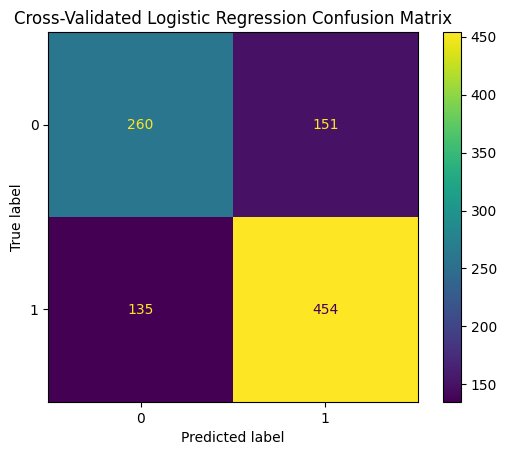

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score


# ============================================================
# Step 2: Load Dataset
# ============================================================



df = pd.read_excel("crop_loan_dataset_realistic.xlsx")

df.head()


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

df = df.drop(columns=["Application_ID"])

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Split Data
# ============================================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ============================================================
# Step 5: Train Logistic Regression Model
# ============================================================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# ============================================================
# Step 6: Prediction
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# Step 7: Cross-Validation
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("\nCross-Validation Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

# Get cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=kf)

# Calculate the confusion matrix using the full dataset and CV predictions
cm_cv = confusion_matrix(y, y_pred_cv)
print("\nCross-Validated Confusion Matrix:\n", cm_cv)

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Cross-Validated Logistic Regression Confusion Matrix")
plt.show()

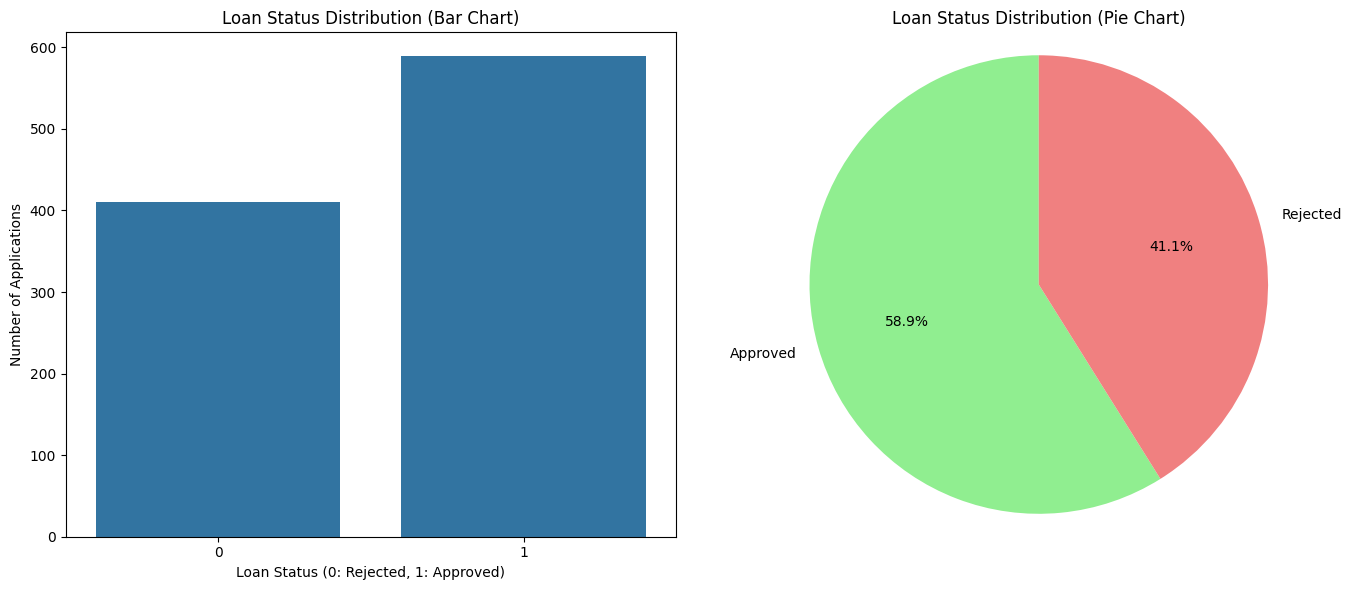

In [ ]:
loan_status_counts = df['Loan_Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
sns.barplot(x=loan_status_counts.index, y=loan_status_counts.values, ax=axes[0])
axes[0].set_title('Loan Status Distribution (Bar Chart)')
axes[0].set_xlabel('Loan Status (0: Rejected, 1: Approved)')
axes[0].set_ylabel('Number of Applications')

# Pie Chart
axes[1].pie(loan_status_counts.values, labels=['Approved', 'Rejected'], autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
axes[1].set_title('Loan Status Distribution (Pie Chart)')
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

### Crop Type vs. Loan Status

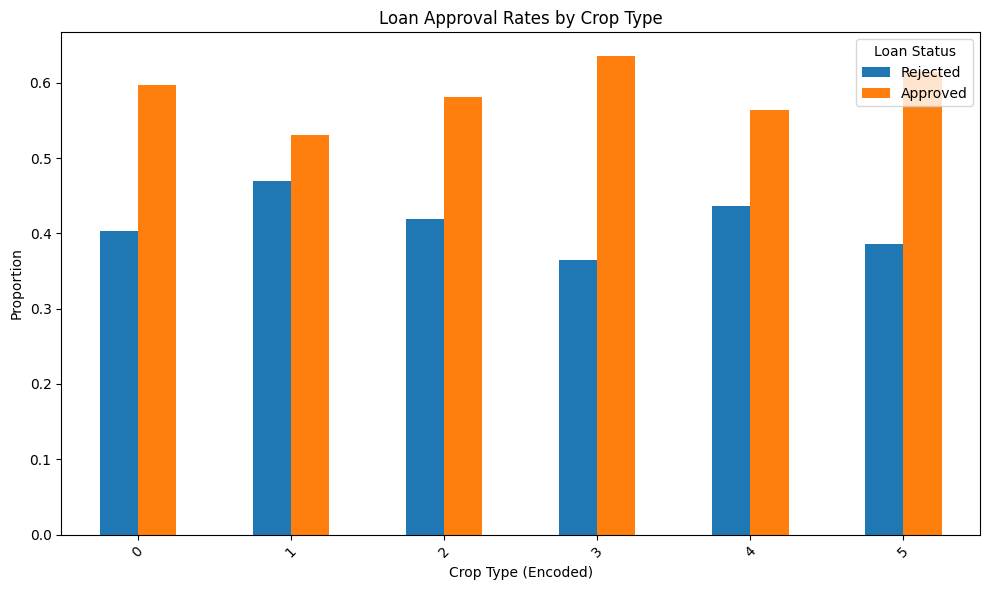

In [ ]:
crop_loan = df.groupby(['Crop_Type', 'Loan_Status']).size().unstack(fill_value=0)
crop_loan_percentage = crop_loan.apply(lambda x: x / x.sum(), axis=1)

crop_loan_percentage.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Loan Approval Rates by Crop Type')
plt.xlabel('Crop Type (Encoded)')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.tight_layout()
plt.show()

### Credit History vs. Loan Status

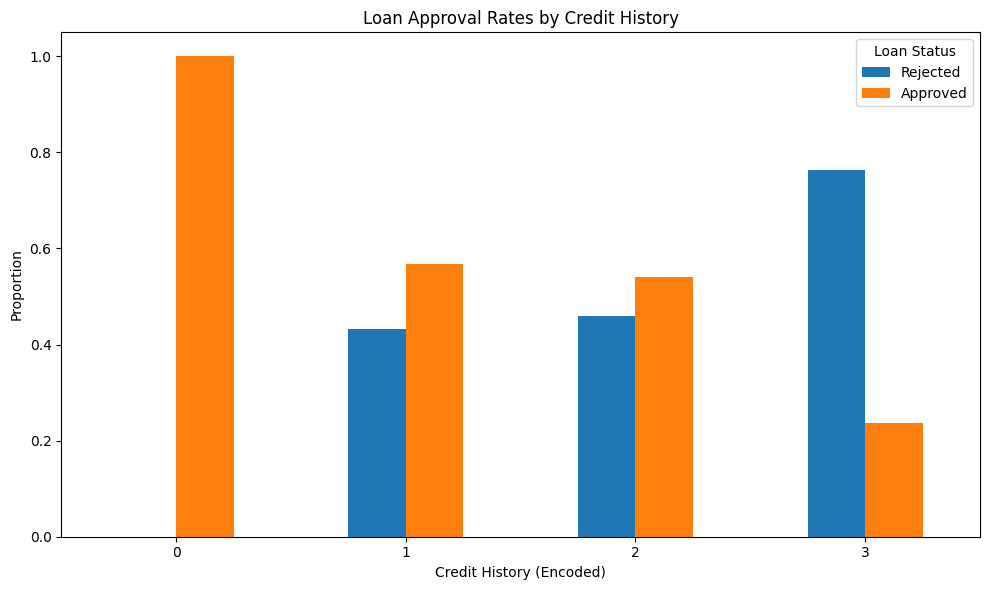

In [ ]:
credit_loan = df.groupby(['Credit_History', 'Loan_Status']).size().unstack(fill_value=0)
credit_loan_percentage = credit_loan.apply(lambda x: x / x.sum(), axis=1)

credit_loan_percentage.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Loan Approval Rates by Credit History')
plt.xlabel('Credit History (Encoded)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.tight_layout()
plt.show()